# Análisis de Series de Tiempo: Futuros de Bitcoin (BTC-USD)
## Modelado ARIMA con criterios AIC, BIC y HQIC

**Objetivo:** Ajustar modelos ARIMA para predecir el precio de Bitcoin (BTC-USD) con horizontes de 7, 14, 21 y 28 días, empleando predicciones *rolling* y directas. Se comparan los criterios de selección AIC (Akaike), BIC (Bayesiano) y HQIC (Hannan-Quinn).

**Metodología:** Se sigue el flujo canónico Box-Jenkins:
1. Identificación (estacionariedad, ACF/PACF)
2. Estimación (selección automática por criterio de información)
3. Diagnóstico (residuales: normalidad e independencia)
4. Predicción (rolling 1-día y directa)
5. Evaluación (MAPE, MAE, RMSE, MSE, R²)

---

## 0. Instalación y Configuración de Librerías

In [1]:
# Instalación de dependencias (ejecutar si es necesario)
# !pip install yfinance pmdarima statsmodels pandas numpy matplotlib seaborn scikit-learn

import warnings
warnings.filterwarnings('ignore')

# ── Datos y manipulación ──────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Series de tiempo ──────────────────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import shapiro, normaltest
import pmdarima as pm

# ── Métricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Configuración global ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
SEED = 42
np.random.seed(SEED)
print('Librerías cargadas correctamente.')
print(f'  pmdarima  : {pm.__version__}')
print(f'  statsmodels ya cargado vía pmdarima')

Librerías cargadas correctamente.
  pmdarima  : 2.1.1
  statsmodels ya cargado vía pmdarima


---
## 1. Descarga de Datos — Yahoo Finance API

Se descarga la serie histórica completa de BTC-USD (precio de cierre ajustado diario) desde su primera cotización disponible hasta hoy. Los futuros de Bitcoin en Yahoo Finance se identifican con el ticker `BTC-USD`.

In [2]:
TICKER  = 'BTC-USD'
END     = datetime.today().strftime('%Y-%m-%d')
START   = '2014-09-17'  # Primera fecha con datos confiables en Yahoo Finance

raw = yf.download(TICKER, start=START, end=END, progress=False)

# Usar precio de cierre ajustado
btc = raw[['Close']].copy()
btc.columns = ['Price']
btc.index   = pd.DatetimeIndex(btc.index).normalize()  # Eliminar info de timezone
btc.dropna(inplace=True)

print(f'Serie descargada: {TICKER}')
print(f'  Rango temporal : {btc.index[0].date()} → {btc.index[-1].date()}')
print(f'  Observaciones  : {len(btc):,}')
print(f'  Precio mín/máx : ${btc.Price.min():,.2f} / ${btc.Price.max():,.2f}')
btc.tail()

Serie descargada: BTC-USD
  Rango temporal : 2014-09-17 → 2026-04-03
  Observaciones  : 4,217
  Precio mín/máx : $178.10 / $124,752.53


,Price
Date,
2026-03-30,66691.445312
2026-03-31,68233.312500
2026-04-01,68078.554688
2026-04-02,66888.570312
2026-04-03,66931.101562


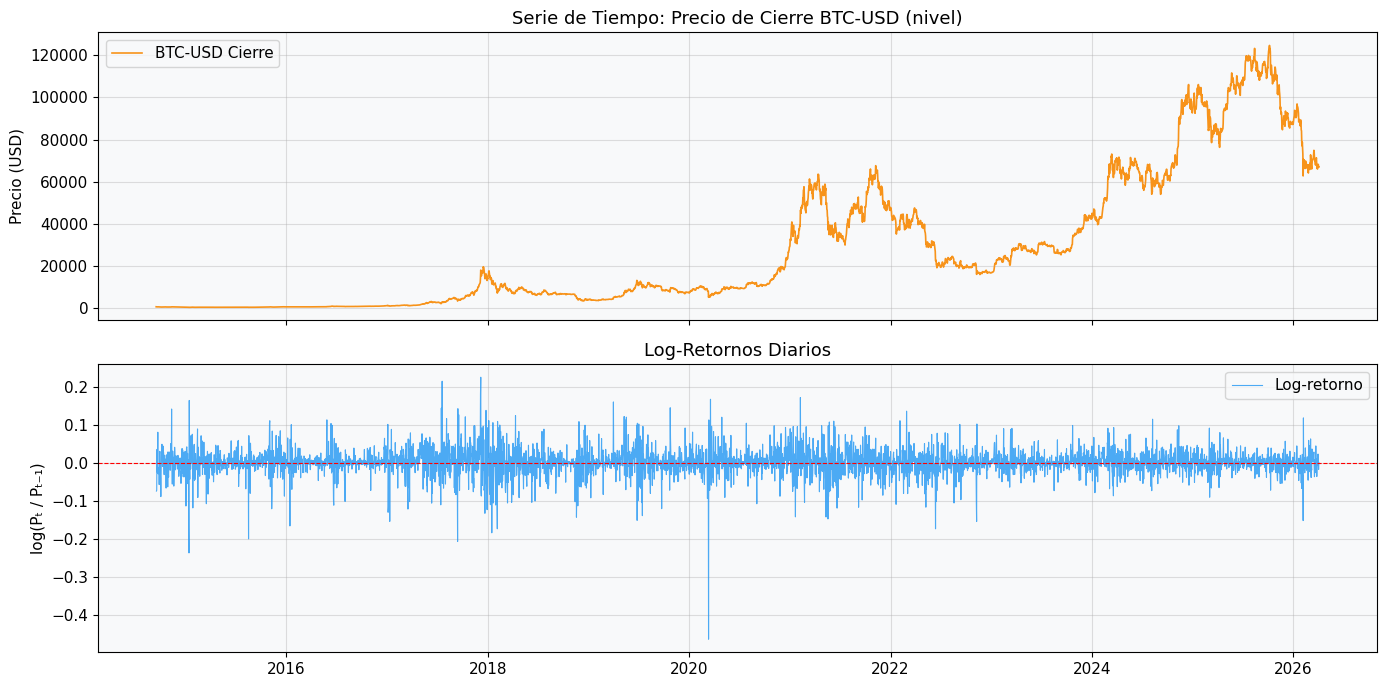


[Conclusión] La serie en nivel exhibe una tendencia estocástica pronunciada (no estacionaria). Los log-retornos son estacionarios visualmente (media ≈ 0), pero con clusters de volatilidad (heterocedasticidad condicional — característica típica de activos financieros).


In [3]:
# ── Visualización de la serie completa ────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(btc.index, btc.Price, color='#F7931A', lw=1.2, label='BTC-USD Cierre')
axes[0].set_title('Serie de Tiempo: Precio de Cierre BTC-USD (nivel)')
axes[0].set_ylabel('Precio (USD)')
axes[0].legend()

# Log-retornos diarios
btc['LogReturn'] = np.log(btc.Price / btc.Price.shift(1))
axes[1].plot(btc.index, btc.LogReturn, color='#2196F3', lw=0.8, alpha=0.8, label='Log-retorno')
axes[1].axhline(0, color='red', lw=0.8, ls='--')
axes[1].set_title('Log-Retornos Diarios')
axes[1].set_ylabel('log(Pₜ / Pₜ₋₁)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig1_serie_completa.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n[Conclusión] La serie en nivel exhibe una tendencia estocástica pronunciada (no estacionaria).'
      ' Los log-retornos son estacionarios visualmente (media ≈ 0), pero con clusters de volatilidad '
      '(heterocedasticidad condicional — característica típica de activos financieros).')

---
## 2. Análisis de Estacionariedad

La estacionariedad es condición necesaria para ARIMA. Se aplican dos tests complementarios:
- **ADF** (Augmented Dickey-Fuller): H₀ = existe raíz unitaria (no estacionaria)
- **KPSS** (Kwiatkowski-Phillips-Schmidt-Shin): H₀ = serie es estacionaria

Los tests se aplican al precio en nivel y a su diferencia de primer orden.

In [4]:
def test_estacionariedad(serie, nombre, alpha=0.05):
    """Ejecuta ADF y KPSS; imprime resultados en tabla compacta."""
    s = serie.dropna()
    
    # ADF
    adf_stat, adf_p, adf_lags, _, adf_cv, _ = adfuller(s, autolag='AIC')
    adf_conclusion = 'Estacionaria ✓' if adf_p < alpha else 'No estacionaria ✗'
    
    # KPSS
    kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(s, regression='c', nlags='auto')
    kpss_conclusion = 'Estacionaria ✓' if kpss_p > alpha else 'No estacionaria ✗'
    
    print(f'\n{'─'*55}')
    print(f'  Serie: {nombre}')
    print(f'{'─'*55}')
    print(f'  Test ADF  │ Estadístico={adf_stat:8.4f} │ p={adf_p:.4f} │ Lags={adf_lags} │ {adf_conclusion}')
    print(f'  Test KPSS │ Estadístico={kpss_stat:8.4f} │ p={kpss_p:.4f} │ Lags={kpss_lags} │ {kpss_conclusion}')
    print(f'  Valores críticos ADF  (1%, 5%, 10%): {list(adf_cv.values())}')
    print(f'  Valores críticos KPSS (10%, 5%, 2.5%, 1%): {list(kpss_cv.values())}')
    
    return {
        'adf_stat': adf_stat, 'adf_p': adf_p,
        'kpss_stat': kpss_stat, 'kpss_p': kpss_p,
        'adf_conclusion': adf_conclusion, 'kpss_conclusion': kpss_conclusion
    }

res_nivel = test_estacionariedad(btc.Price, 'Precio BTC-USD (nivel)')
res_diff1 = test_estacionariedad(btc.Price.diff(), 'ΔPrecio BTC-USD (1ª diferencia)')
res_log   = test_estacionariedad(btc.LogReturn, 'Log-Retornos BTC-USD')

print('\n[Conclusión] La serie en nivel NO es estacionaria (ADF no rechaza raíz unitaria, '
      'KPSS rechaza estacionariedad). La primera diferencia y los log-retornos sí son '
      'estacionarios → orden de integración d=1. ARIMA(p,1,q) es apropiado.')

C:\Users\User\AppData\Local\Temp\ipykernel_62576\695906000.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(s, regression='c', nlags='auto')
C:\Users\User\AppData\Local\Temp\ipykernel_62576\695906000.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(s, regression='c', nlags='auto')



───────────────────────────────────────────────────────
  Serie: Precio BTC-USD (nivel)
───────────────────────────────────────────────────────
  Test ADF  │ Estadístico= -1.2234 │ p=0.6635 │ Lags=31 │ No estacionaria ✗
  Test KPSS │ Estadístico=  7.5346 │ p=0.0100 │ Lags=40 │ No estacionaria ✗
  Valores críticos ADF  (1%, 5%, 10%): [-3.431913516254953, -2.8622308755064814, -2.5671377589502247]
  Valores críticos KPSS (10%, 5%, 2.5%, 1%): [0.347, 0.463, 0.574, 0.739]

───────────────────────────────────────────────────────
  Serie: ΔPrecio BTC-USD (1ª diferencia)
───────────────────────────────────────────────────────
  Test ADF  │ Estadístico= -9.9386 │ p=0.0000 │ Lags=30 │ Estacionaria ✓
  Test KPSS │ Estadístico=  0.0766 │ p=0.1000 │ Lags=2 │ Estacionaria ✓
  Valores críticos ADF  (1%, 5%, 10%): [-3.431913516254953, -2.8622308755064814, -2.5671377589502247]
  Valores críticos KPSS (10%, 5%, 2.5%, 1%): [0.347, 0.463, 0.574, 0.739]



───────────────────────────────────────────────────────
  Serie: Log-Retornos BTC-USD
───────────────────────────────────────────────────────
  Test ADF  │ Estadístico=-19.7491 │ p=0.0000 │ Lags=9 │ Estacionaria ✓
  Test KPSS │ Estadístico=  0.1465 │ p=0.1000 │ Lags=13 │ Estacionaria ✓
  Valores críticos ADF  (1%, 5%, 10%): [-3.4319057050536026, -2.862227424850339, -2.5671359219817984]
  Valores críticos KPSS (10%, 5%, 2.5%, 1%): [0.347, 0.463, 0.574, 0.739]

[Conclusión] La serie en nivel NO es estacionaria (ADF no rechaza raíz unitaria, KPSS rechaza estacionariedad). La primera diferencia y los log-retornos sí son estacionarios → orden de integración d=1. ARIMA(p,1,q) es apropiado.


C:\Users\User\AppData\Local\Temp\ipykernel_62576\695906000.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(s, regression='c', nlags='auto')


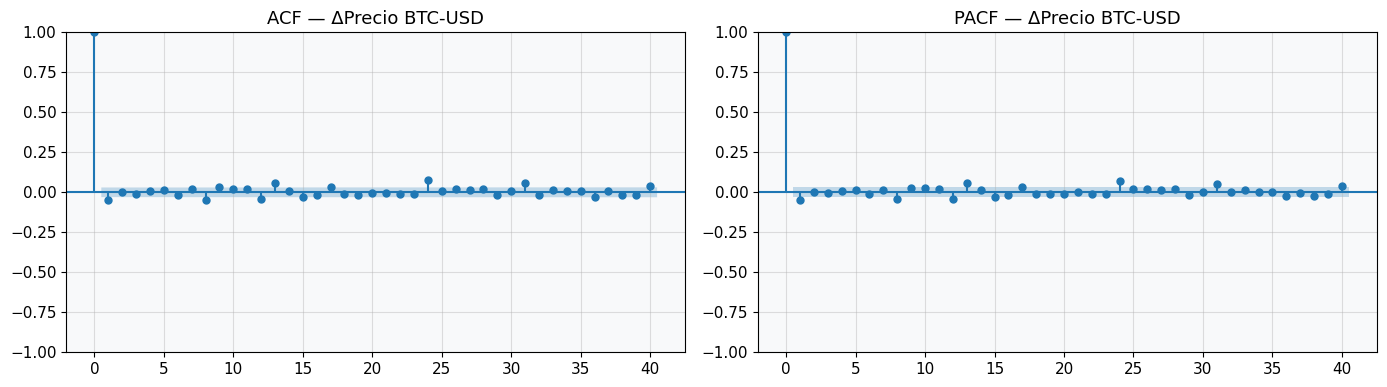


[Conclusión] ACF y PACF de la serie diferenciada muestran caída rápida sin patrones estacionales marcados. Los órdenes p y q serán determinados automáticamente por criterios de información.


In [5]:
# ── ACF y PACF de la serie diferenciada ──────────────────────────────────────
serie_diff = btc.Price.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(serie_diff, lags=40, alpha=0.05, ax=axes[0], title='ACF — ΔPrecio BTC-USD')
plot_pacf(serie_diff, lags=40, alpha=0.05, ax=axes[1], title='PACF — ΔPrecio BTC-USD', method='ywm')
plt.tight_layout()
plt.savefig('fig2_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n[Conclusión] ACF y PACF de la serie diferenciada muestran caída rápida sin patrones '
      'estacionales marcados. Los órdenes p y q serán determinados automáticamente por '
      'criterios de información.')

---
## 3. Partición Train / Test

Según la consigna: el conjunto de entrenamiento es **Nₘ − 28** observaciones (el resto hacia el final de la serie constituye el conjunto de test máximo). Se generan 4 conjuntos de test superpuestos con horizontes 7, 14, 21 y 28 días.

In [6]:
HORIZONTES = [7, 14, 21, 28]
N = len(btc)
N_TRAIN_BASE = N - 28  # Entrenamiento para el horizonte más largo

print(f'Total de observaciones (N): {N}')
print(f'Tamaño de entrenamiento base (N-28): {N_TRAIN_BASE}')
print()

splits = {}
for h in HORIZONTES:
    n_train = N - h
    train   = btc.Price.iloc[:n_train]
    test    = btc.Price.iloc[n_train:]
    splits[h] = {'train': train, 'test': test, 'n_train': n_train}
    print(f'  Horizonte {h:2d}d │ Train: {n_train} obs ({train.index[0].date()} → {train.index[-1].date()}) '
          f'│ Test: {len(test)} obs ({test.index[0].date()} → {test.index[-1].date()})')

print('\n[Contexto] La ventana de test se extiende desde el final de la serie. '
      'El modelo se entrena sobre toda la historia previa al período de test.')

Total de observaciones (N): 4217
Tamaño de entrenamiento base (N-28): 4189

  Horizonte  7d │ Train: 4210 obs (2014-09-17 → 2026-03-27) │ Test: 7 obs (2026-03-28 → 2026-04-03)
  Horizonte 14d │ Train: 4203 obs (2014-09-17 → 2026-03-20) │ Test: 14 obs (2026-03-21 → 2026-04-03)
  Horizonte 21d │ Train: 4196 obs (2014-09-17 → 2026-03-13) │ Test: 21 obs (2026-03-14 → 2026-04-03)
  Horizonte 28d │ Train: 4189 obs (2014-09-17 → 2026-03-06) │ Test: 28 obs (2026-03-07 → 2026-04-03)

[Contexto] La ventana de test se extiende desde el final de la serie. El modelo se entrena sobre toda la historia previa al período de test.


---
## 4. Selección del Modelo ARIMA — Criterio AIC (Akaike)

Se usa `pmdarima.auto_arima` que implementa una búsqueda escalonada (stepwise) sobre el espacio (p,d,q) minimizando el criterio de información seleccionado. Parámetros clave:
- `d=1` fijado por el análisis de estacionariedad
- `max_p=5, max_q=5` para controlar la complejidad
- `information_criterion='aic'`

In [7]:
def seleccionar_arima(train_series, criterion='aic', d=1, max_p=5, max_q=5, verbose=False):
    """Selecciona el mejor ARIMA mediante auto_arima con el criterio especificado."""
    modelo = pm.auto_arima(
        train_series,
        d=d,
        start_p=0, max_p=max_p,
        start_q=0, max_q=max_q,
        information_criterion=criterion,
        stepwise=True,
        seasonal=False,
        suppress_warnings=True,
        error_action='ignore',
        trace=verbose
    )
    return modelo

# Selección AIC para cada horizonte
modelos_aic = {}
print('=== Selección de modelos ARIMA — Criterio AIC ===')
print(f'{"Horizonte":>10} {"Orden (p,d,q)":>15} {"AIC":>12} {"BIC":>12} {"HQIC":>12}')
print('─'*65)

for h in HORIZONTES:
    train = splits[h]['train']
    modelo = seleccionar_arima(train, criterion='aic')
    modelos_aic[h] = modelo
    order = modelo.order
    aic   = modelo.aic()
    bic   = modelo.bic()
    # HQIC no expuesto directamente, se obtiene del fit interno
    try:
        hqic = modelo.arima_res_.hqic
    except:
        hqic = np.nan
    print(f'{h:>8}d {str(order):>15} {aic:>12.2f} {bic:>12.2f} {hqic:>12.2f}')
    modelos_aic[h] = {'model': modelo, 'order': order, 'aic': aic, 'bic': bic, 'hqic': hqic}

print('\n[Conclusión] auto_arima evalúa modelos de forma escalonada maximizando la '
      'verosimilitud penalizada. El AIC penaliza con 2k (k = número de parámetros), '
      'favoreciendo modelos más parsimoniosos.')

=== Selección de modelos ARIMA — Criterio AIC ===
 Horizonte   Orden (p,d,q)          AIC          BIC         HQIC
─────────────────────────────────────────────────────────────────


       7d       (1, 1, 0)     71189.53     71202.22     71194.02


      14d       (1, 1, 0)     71057.53     71070.22     71062.02


      21d       (1, 1, 0)     70932.44     70945.12     70936.93


      28d       (1, 1, 0)     70812.12     70824.80     70816.61

[Conclusión] auto_arima evalúa modelos de forma escalonada maximizando la verosimilitud penalizada. El AIC penaliza con 2k (k = número de parámetros), favoreciendo modelos más parsimoniosos.


In [8]:
# Resumen detallado del modelo para horizonte de 28 días (el más informativo)
print('=== Resumen ARIMA — Horizonte 28 días (criterio AIC) ===')
print(modelos_aic[28]['model'].summary())

=== Resumen ARIMA — Horizonte 28 días (criterio AIC) ===
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4189
Model:               SARIMAX(1, 1, 0)   Log Likelihood              -35404.062
Date:                Sat, 04 Apr 2026   AIC                          70812.125
Time:                        19:20:06   BIC                          70824.805
Sample:                    09-17-2014   HQIC                         70816.609
                         - 03-06-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0484      0.008     -6.388      0.000      -0.063      -0.034
sigma2      1.289e+06   1.09e+04    118.763      0.000    1.27e+06    1.31

---
## 5. Diagnóstico de Residuales — Modelos AIC

Un modelo ARIMA bien especificado debe producir residuales que sean:
1. **Independientes** (ruido blanco): Test de Ljung-Box — H₀: no hay autocorrelación
2. **Normales**: Test de Shapiro-Wilk (muestras <5000) y Jarque-Bera — H₀: normalidad
3. **Homocedasticos**: Inspección visual de residuales al cuadrado


  Diagnóstico residuales — Horizonte 7d (AIC)
  Orden ARIMA: (1, 1, 0)   │   N_residuales: 4210
────────────────────────────────────────────────────────────
  Ljung-Box  (lag=20) │ Q= 51.4292 │ p=0.0001 │ Autocorrelación detectada ✗
  Jarque-Bera        │ JB=22466.8517 │ p=0.0000 │ No normales ✗
  Shapiro-Wilk       │ W =  0.7646 │ p=0.0000 │ No normales ✗


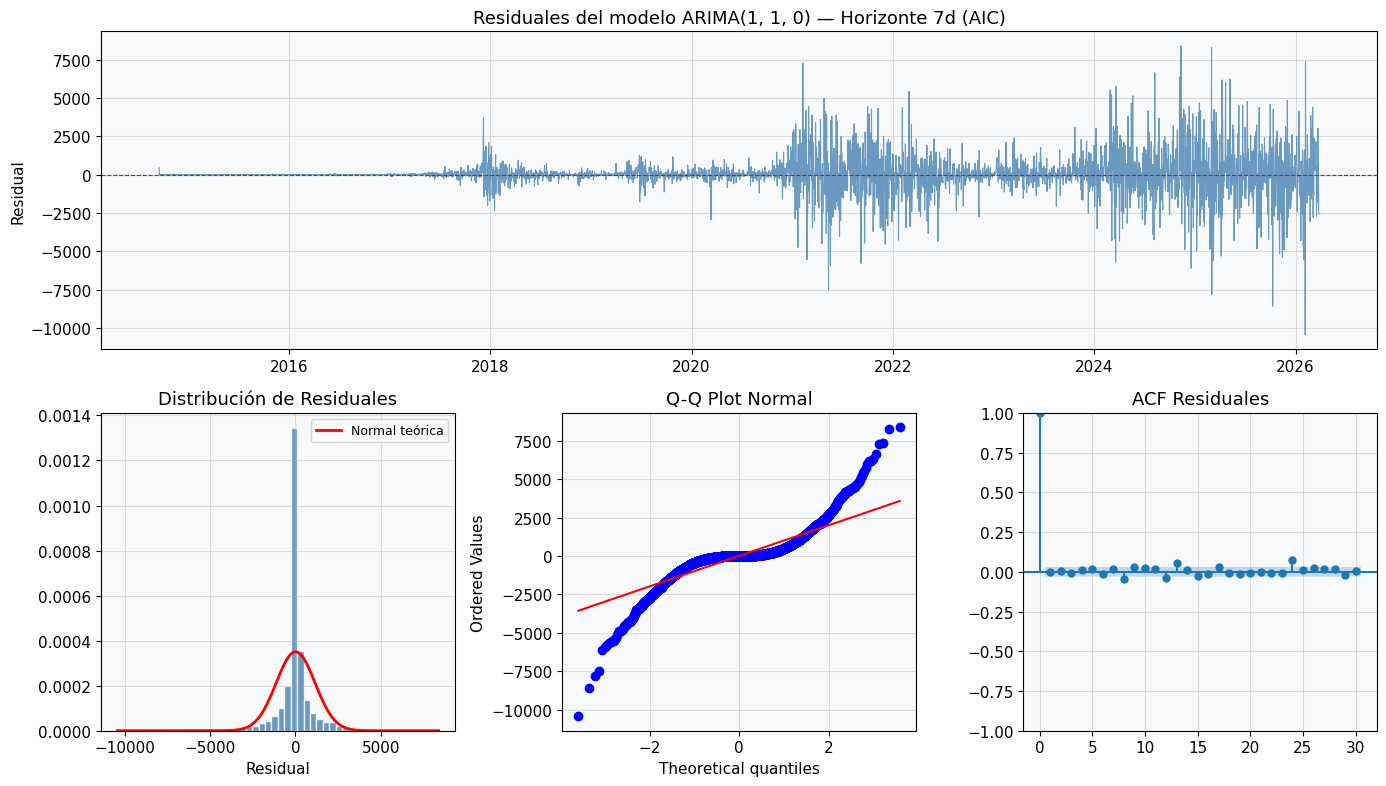


  Diagnóstico residuales — Horizonte 14d (AIC)
  Orden ARIMA: (1, 1, 0)   │   N_residuales: 4203
────────────────────────────────────────────────────────────
  Ljung-Box  (lag=20) │ Q= 53.4197 │ p=0.0001 │ Autocorrelación detectada ✗
  Jarque-Bera        │ JB=22797.9482 │ p=0.0000 │ No normales ✗
  Shapiro-Wilk       │ W =  0.7632 │ p=0.0000 │ No normales ✗


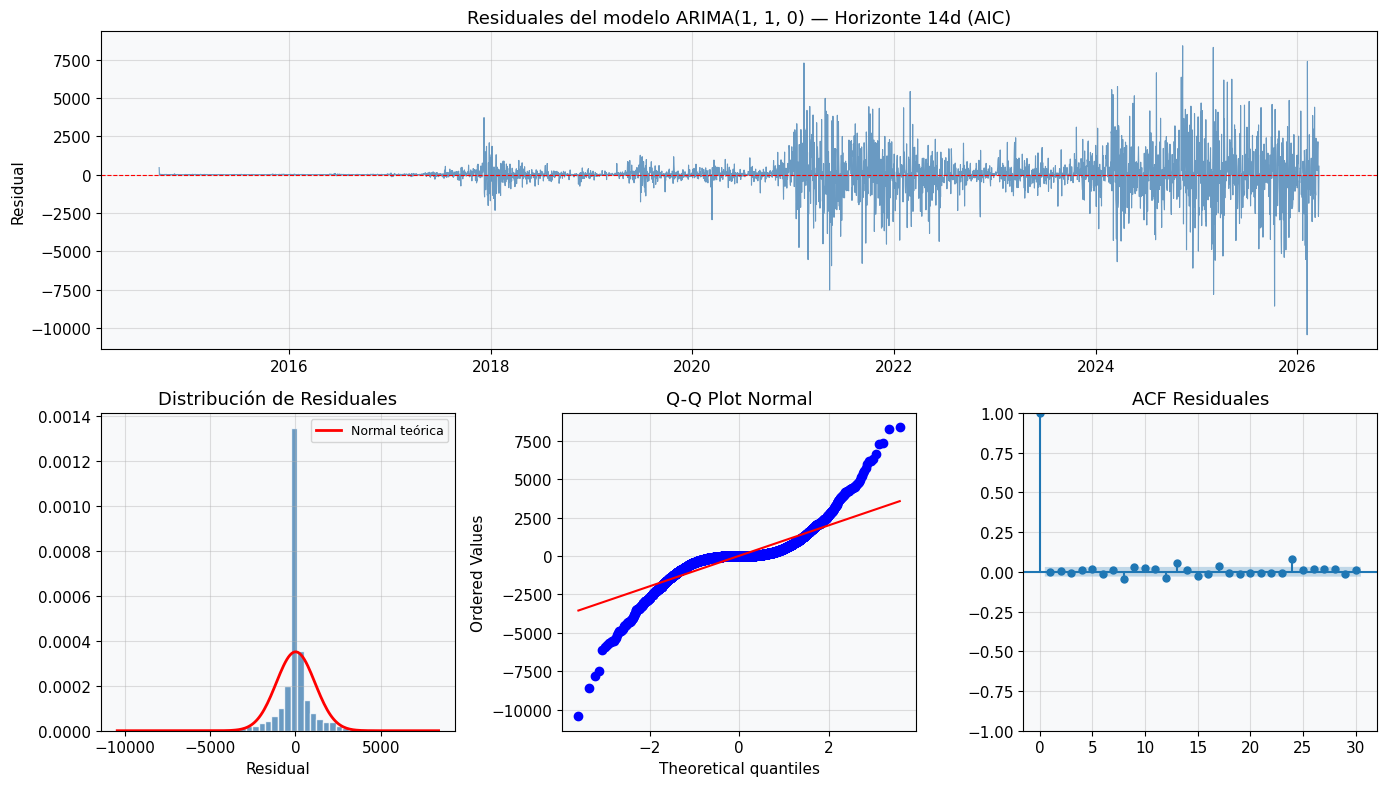


  Diagnóstico residuales — Horizonte 21d (AIC)
  Orden ARIMA: (1, 1, 0)   │   N_residuales: 4196
────────────────────────────────────────────────────────────
  Ljung-Box  (lag=20) │ Q= 53.8822 │ p=0.0001 │ Autocorrelación detectada ✗
  Jarque-Bera        │ JB=22987.6244 │ p=0.0000 │ No normales ✗
  Shapiro-Wilk       │ W =  0.7621 │ p=0.0000 │ No normales ✗


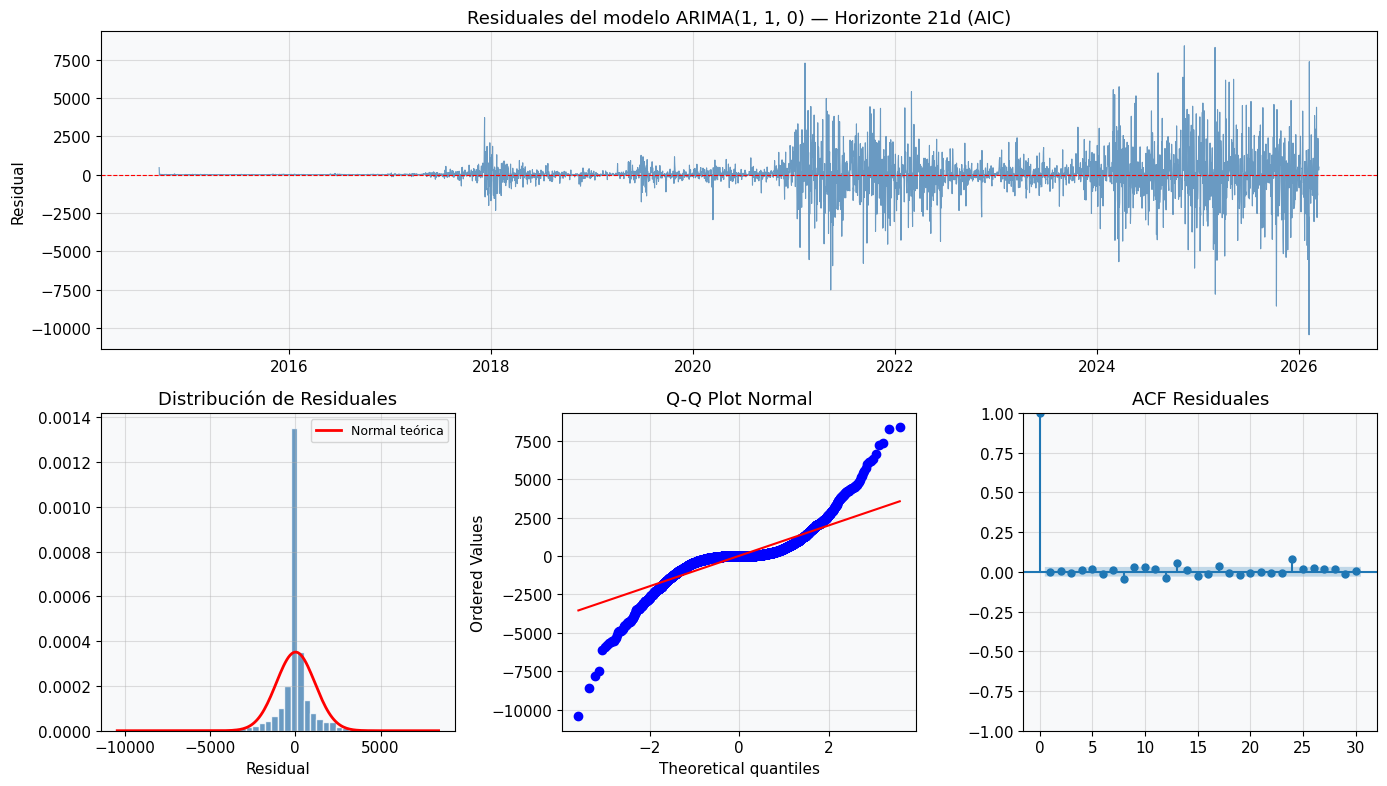


  Diagnóstico residuales — Horizonte 28d (AIC)
  Orden ARIMA: (1, 1, 0)   │   N_residuales: 4189
────────────────────────────────────────────────────────────
  Ljung-Box  (lag=20) │ Q= 54.0923 │ p=0.0001 │ Autocorrelación detectada ✗
  Jarque-Bera        │ JB=23071.2221 │ p=0.0000 │ No normales ✗
  Shapiro-Wilk       │ W =  0.7612 │ p=0.0000 │ No normales ✗


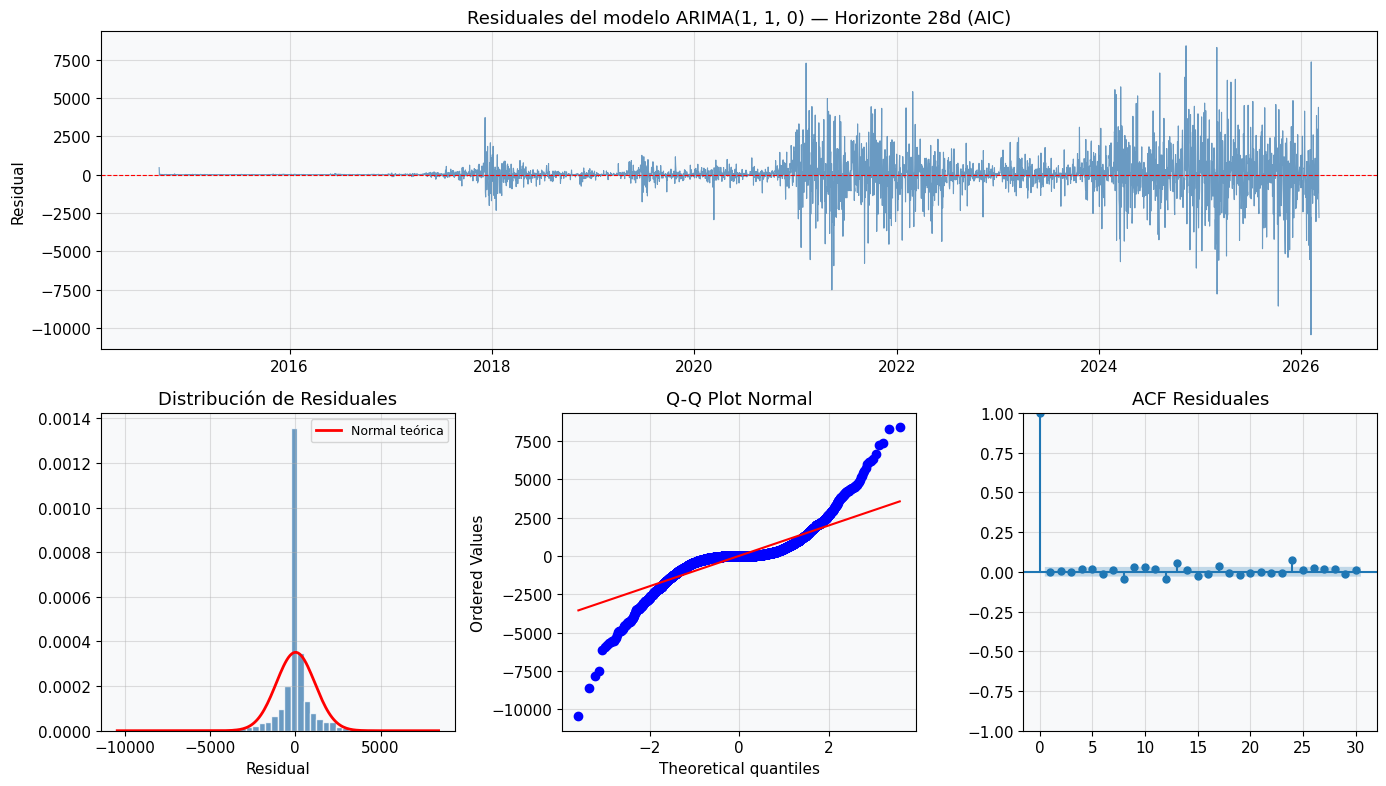

In [9]:
def diagnostico_residuales(modelo_dict, horizonte, criterion_name='AIC', alpha=0.05):
    """Realiza diagnóstico completo de residuales del modelo ajustado."""
    modelo = modelo_dict['model']
    res    = modelo.resid()
    orden  = modelo_dict['order']

    # ── Tests estadísticos ────────────────────────────────────────────────────
    # Ljung-Box (independencia) — lag=min(10, N//5)
    lb_lag = min(20, len(res)//5)
    lb_result = acorr_ljungbox(res, lags=[lb_lag], return_df=True)
    lb_stat = lb_result['lb_stat'].values[0]
    lb_p    = lb_result['lb_pvalue'].values[0]
    lb_concl = 'Independientes ✓' if lb_p > alpha else 'Autocorrelación detectada ✗'

    # Jarque-Bera (normalidad)
    jb_stat, jb_p, _, _ = jarque_bera(res)
    jb_concl = 'Normales ✓' if jb_p > alpha else 'No normales ✗'

    # Shapiro-Wilk (sobre muestra si es grande)
    sw_sample = res[:5000] if len(res) > 5000 else res
    sw_stat, sw_p = shapiro(sw_sample)
    sw_concl = 'Normales ✓' if sw_p > alpha else 'No normales ✗'

    print(f'\n{'='*60}')
    print(f'  Diagnóstico residuales — Horizonte {horizonte}d ({criterion_name})')
    print(f'  Orden ARIMA: {orden}   │   N_residuales: {len(res)}')
    print(f'{'─'*60}')
    print(f'  Ljung-Box  (lag={lb_lag:2d}) │ Q={lb_stat:8.4f} │ p={lb_p:.4f} │ {lb_concl}')
    print(f'  Jarque-Bera        │ JB={jb_stat:8.4f} │ p={jb_p:.4f} │ {jb_concl}')
    print(f'  Shapiro-Wilk       │ W ={sw_stat:8.4f} │ p={sw_p:.4f} │ {sw_concl}')

    # ── Gráficos ──────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(14, 8))
    gs  = GridSpec(2, 3, figure=fig)

    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(res, color='steelblue', lw=0.8, alpha=0.8)
    ax1.axhline(0, color='red', lw=0.8, ls='--')
    ax1.set_title(f'Residuales del modelo ARIMA{orden} — Horizonte {horizonte}d ({criterion_name})')
    ax1.set_ylabel('Residual')

    ax2 = fig.add_subplot(gs[1, 0])
    ax2.hist(res, bins=50, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    from scipy.stats import norm
    x_range = np.linspace(res.min(), res.max(), 200)
    ax2.plot(x_range, norm.pdf(x_range, res.mean(), res.std()), 'r-', lw=2, label='Normal teórica')
    ax2.set_title('Distribución de Residuales')
    ax2.set_xlabel('Residual')
    ax2.legend(fontsize=9)

    ax3 = fig.add_subplot(gs[1, 1])
    from scipy.stats import probplot
    probplot(res, dist='norm', plot=ax3)
    ax3.set_title('Q-Q Plot Normal')

    ax4 = fig.add_subplot(gs[1, 2])
    plot_acf(res, lags=30, alpha=0.05, ax=ax4, title='ACF Residuales')

    plt.tight_layout()
    plt.savefig(f'fig_diag_{criterion_name.lower()}_h{horizonte}.png', dpi=130, bbox_inches='tight')
    plt.show()

    return {'lb_p': lb_p, 'jb_p': jb_p, 'sw_p': sw_p,
            'lb_concl': lb_concl, 'jb_concl': jb_concl, 'sw_concl': sw_concl}

diag_aic = {}
for h in HORIZONTES:
    diag_aic[h] = diagnostico_residuales(modelos_aic[h], h, 'AIC')

---
## 6. Predicción Rolling (ventana de 1 día) — Criterio AIC

**Rolling forecast:** En cada paso del período de test se re-estima el modelo añadiendo la observación real más reciente, y se genera una predicción de 1 paso al frente. Este esquema simula un agente que actualiza el modelo cada día con el dato real observado.

$$\hat{y}_{t+1} = f(\{y_1, y_2, \ldots, y_t\})$$

Para un horizonte $h$, se realizan $h$ actualizaciones y $h$ predicciones de un paso.

In [10]:
def rolling_forecast(train_series, test_series, order, n_steps=1):
    """
    Realiza rolling forecast de 1-paso.
    En cada iteración: re-ajusta el modelo con la historia actualizada
    y predice el siguiente valor.
    """
    history      = list(train_series)
    predictions  = []
    conf_ints    = []

    for i, actual in enumerate(test_series):
        # Ajustar modelo con historia actual
        model_fit = ARIMA(history, order=order).fit()
        # Forecast 1 paso
        fc   = model_fit.get_forecast(steps=n_steps)
        pred = fc.predicted_mean.iloc[0]
        ci   = fc.conf_int(alpha=0.05)
        predictions.append(pred)
        conf_ints.append((ci.iloc[0, 0], ci.iloc[0, 1]))
        # Incorporar observación real
        history.append(actual)

    pred_series = pd.Series(predictions, index=test_series.index)
    ci_df       = pd.DataFrame(conf_ints, index=test_series.index, columns=['lower_95', 'upper_95'])
    return pred_series, ci_df


print('Ejecutando predicciones rolling (AIC)... esto puede tardar varios minutos.')
rolling_preds_aic = {}

for h in HORIZONTES:
    train = splits[h]['train']
    test  = splits[h]['test']
    order = modelos_aic[h]['order']
    print(f'  → Horizonte {h}d │ ARIMA{order} │ {len(test)} iteraciones...')
    preds, ci_df = rolling_forecast(train, test, order)
    rolling_preds_aic[h] = {'preds': preds, 'ci': ci_df, 'test': test}
    print(f'     ✓ Completado')

print('\nRolling forecast AIC completado.')

Ejecutando predicciones rolling (AIC)... esto puede tardar varios minutos.
  → Horizonte 7d │ ARIMA(1, 1, 0) │ 7 iteraciones...


AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [ ]:
# ── Visualización rolling forecasts AIC ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
colors_h = ['#1E88E5', '#43A047', '#FB8C00', '#E53935']

for i, h in enumerate(HORIZONTES):
    ax  = axes[i]
    rp  = rolling_preds_aic[h]
    trn = splits[h]['train']
    tst = rp['test']
    prd = rp['preds']
    ci  = rp['ci']

    # Últimas 60 obs de train para contexto visual
    ctx = trn.iloc[-60:]
    ax.plot(ctx.index, ctx.values, color='gray', lw=1, alpha=0.6, label='Histórico')
    ax.plot(tst.index, tst.values, color='black', lw=1.5, label='Real')
    ax.plot(prd.index, prd.values, color=colors_h[i], lw=1.5, ls='--', label=f'Pronóstico rolling')
    ax.fill_between(ci.index, ci.lower_95, ci.upper_95, color=colors_h[i], alpha=0.15, label='IC 95%')
    ax.axvline(tst.index[0], color='red', lw=0.8, ls=':', alpha=0.7)
    ax.set_title(f'Rolling Forecast — {h} días (AIC)')
    ax.set_ylabel('Precio BTC-USD ($)')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Predicción Rolling 1-paso — ARIMA (Criterio AIC)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig3_rolling_aic.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Predicción Directa (sin rolling) — `forecast()` — Criterio AIC

**Forecast directo:** El modelo se entrena una sola vez sobre el conjunto de entrenamiento y genera de forma directa los $h$ pasos futuros. No hay actualización con observaciones reales del período de test.

$$[\hat{y}_{T+1}, \hat{y}_{T+2}, \ldots, \hat{y}_{T+h}] = \text{ARIMA}\text{.forecast}(h)$$

Las bandas de incertidumbre se amplían con el horizonte: $\text{Var}(e_{T+h|T}) \geq \text{Var}(e_{T+1|T})$.

In [ ]:
def direct_forecast(train_series, test_series, order):
    """
    Forecast directo: un único ajuste del modelo, se proyecta
    h pasos al frente sin actualizar con datos del período de test.
    """
    model_fit = ARIMA(train_series, order=order).fit()
    h         = len(test_series)
    fc        = model_fit.get_forecast(steps=h)
    preds     = fc.predicted_mean
    preds.index = test_series.index
    ci        = fc.conf_int(alpha=0.05)
    ci.index  = test_series.index
    ci.columns = ['lower_95', 'upper_95']
    return preds, ci


direct_preds_aic = {}
print('Ejecutando predicciones directas (AIC)...')

for h in HORIZONTES:
    train = splits[h]['train']
    test  = splits[h]['test']
    order = modelos_aic[h]['order']
    preds, ci_df = direct_forecast(train, test, order)
    direct_preds_aic[h] = {'preds': preds, 'ci': ci_df, 'test': test}
    print(f'  ✓ Horizonte {h}d │ ARIMA{order} │ {h} pasos proyectados')

print('Forecast directo AIC completado.')

In [ ]:
# ── Visualización direct forecasts AIC ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, h in enumerate(HORIZONTES):
    ax  = axes[i]
    dp  = direct_preds_aic[h]
    trn = splits[h]['train']
    tst = dp['test']
    prd = dp['preds']
    ci  = dp['ci']

    ctx = trn.iloc[-60:]
    ax.plot(ctx.index, ctx.values, color='gray', lw=1, alpha=0.6, label='Histórico')
    ax.plot(tst.index, tst.values, color='black', lw=1.5, label='Real')
    ax.plot(prd.index, prd.values, color=colors_h[i], lw=1.5, ls='--', label='Pronóstico directo')
    ax.fill_between(ci.index, ci.lower_95, ci.upper_95, color=colors_h[i], alpha=0.15, label='IC 95%')
    ax.axvline(tst.index[0], color='red', lw=0.8, ls=':', alpha=0.7)
    ax.set_title(f'Forecast Directo — {h} días (AIC)')
    ax.set_ylabel('Precio BTC-USD ($)')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Predicción Directa — ARIMA (Criterio AIC)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig4_direct_aic.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n[Conclusión] El forecast directo tiende a la media de largo plazo a medida que '
      'aumenta el horizonte. Las bandas de confianza se amplían, reflejando la '
      'acumulación de incertidumbre al proyectar múltiples pasos.')

---
## 8. Tablas de Error — AIC (Rolling vs. Directo)

Se calculan las métricas estándar para evaluar la calidad predictiva:

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **MAPE** | $\frac{1}{h}\sum|\frac{y_t - \hat{y}_t}{y_t}|\times100$ | Error porcentual absoluto medio |
| **MAE**  | $\frac{1}{h}\sum|y_t - \hat{y}_t|$ | Error absoluto medio (mismas unidades) |
| **RMSE** | $\sqrt{\frac{1}{h}\sum(y_t-\hat{y}_t)^2}$ | Penaliza errores grandes |
| **MSE**  | $\frac{1}{h}\sum(y_t-\hat{y}_t)^2$ | Error cuadrático medio |
| **R²**   | $1 - \frac{SS_{res}}{SS_{tot}}$ | Varianza explicada (−∞ a 1) |

In [ ]:
def calcular_metricas(y_real, y_pred):
    """Devuelve dict con MAPE, MAE, RMSE, MSE, R2."""
    y_real = np.array(y_real)
    y_pred = np.array(y_pred)
    mape  = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    mae   = mean_absolute_error(y_real, y_pred)
    mse   = mean_squared_error(y_real, y_pred)
    rmse  = np.sqrt(mse)
    r2    = r2_score(y_real, y_pred)
    return {'MAPE (%)': mape, 'MAE ($)': mae, 'RMSE ($)': rmse, 'MSE ($²)': mse, 'R²': r2}


def tabla_errores(pred_dict, nombre_metodo, criterion_name='AIC'):
    """Genera tabla de métricas para todos los horizontes."""
    rows = []
    for h in HORIZONTES:
        y_real = pred_dict[h]['test'].values
        y_pred = pred_dict[h]['preds'].values
        m = calcular_metricas(y_real, y_pred)
        m['Horizonte'] = f'{h}d'
        m['Método']    = nombre_metodo
        rows.append(m)
    df = pd.DataFrame(rows).set_index(['Horizonte', 'Método'])
    return df


err_rolling_aic = tabla_errores(rolling_preds_aic, 'Rolling')
err_direct_aic  = tabla_errores(direct_preds_aic,  'Directo')
tabla_aic       = pd.concat([err_rolling_aic, err_direct_aic])

print('=== Tabla de Errores — Criterio AIC ===')
pd.set_option('display.float_format', '{:.4f}'.format)
display(tabla_aic)

print('\n[Conclusión] El método rolling generalmente produce menor error que el directo '
      'porque incorpora información real en cada paso. A mayor horizonte, el error '
      'del método directo aumenta significativamente por la propagación de incertidumbre.')

In [ ]:
# ── Gráfico correlación observado vs predicho ─────────────────────────────────
def plot_correlacion(pred_dict, titulo, fname):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    for i, h in enumerate(HORIZONTES):
        ax  = axes[i]
        yreal = pred_dict[h]['test'].values
        ypred = pred_dict[h]['preds'].values
        r2 = r2_score(yreal, ypred)
        corr = np.corrcoef(yreal, ypred)[0, 1]
        ax.scatter(yreal, ypred, alpha=0.7, color=colors_h[i], edgecolors='white', s=60)
        lims = [min(yreal.min(), ypred.min()), max(yreal.max(), ypred.max())]
        ax.plot(lims, lims, 'r--', lw=1.5, label='y = ŷ (ideal)')
        ax.set_xlabel('Precio Real $y_t$ (USD)')
        ax.set_ylabel('Precio Predicho $\\hat{y}_t$ (USD)')
        ax.set_title(f'Corr$(y_t, \\hat{{y}}_t)$ — {h}d │ r={corr:.4f}, R²={r2:.4f}')
        ax.legend(fontsize=8)
    plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.savefig(fname, dpi=140, bbox_inches='tight')
    plt.show()

plot_correlacion(rolling_preds_aic, 'Correlación Real vs Predicho — Rolling AIC', 'fig5_corr_rolling_aic.png')
plot_correlacion(direct_preds_aic,  'Correlación Real vs Predicho — Directo AIC',  'fig6_corr_direct_aic.png')

---
## 9. Selección ARIMA — Criterios BIC y HQIC

Se repite el proceso de selección utilizando los criterios BIC y HQIC:

| Criterio | Penalización | Tendencia |
|----------|-------------|----------|
| **AIC**  | $2k$ | Modelos más complejos (menor sesgo) |
| **BIC**  | $k\ln(n)$ | Más parsimoniosos (mayor penalización para n grande) |
| **HQIC** | $2k\ln(\ln(n))$ | Intermedio entre AIC y BIC |

Para series largas (n >> 1), $\ln(n) > 2$ → BIC es más restrictivo que AIC.

In [ ]:
# ── Selección BIC ─────────────────────────────────────────────────────────────
modelos_bic = {}
print('=== Selección de modelos ARIMA — Criterio BIC ===')
print(f'{"Horizonte":>10} {"Orden (p,d,q)":>15} {"AIC":>12} {"BIC":>12} {"HQIC":>12}')
print('─'*65)

for h in HORIZONTES:
    train  = splits[h]['train']
    modelo = seleccionar_arima(train, criterion='bic')
    order  = modelo.order
    aic    = modelo.aic()
    bic    = modelo.bic()
    try:
        hqic = modelo.arima_res_.hqic
    except:
        hqic = np.nan
    modelos_bic[h] = {'model': modelo, 'order': order, 'aic': aic, 'bic': bic, 'hqic': hqic}
    print(f'{h:>8}d {str(order):>15} {aic:>12.2f} {bic:>12.2f} {hqic:>12.2f}')

print()
# ── Selección HQIC ────────────────────────────────────────────────────────────
modelos_hqic = {}
print('=== Selección de modelos ARIMA — Criterio HQIC ===')
print(f'{"Horizonte":>10} {"Orden (p,d,q)":>15} {"AIC":>12} {"BIC":>12} {"HQIC":>12}')
print('─'*65)

for h in HORIZONTES:
    train  = splits[h]['train']
    modelo = seleccionar_arima(train, criterion='hqic')
    order  = modelo.order
    aic    = modelo.aic()
    bic    = modelo.bic()
    try:
        hqic = modelo.arima_res_.hqic
    except:
        hqic = np.nan
    modelos_hqic[h] = {'model': modelo, 'order': order, 'aic': aic, 'bic': bic, 'hqic': hqic}
    print(f'{h:>8}d {str(order):>15} {aic:>12.2f} {bic:>12.2f} {hqic:>12.2f}')

print('\n[Conclusión] BIC y HQIC tienden a seleccionar modelos de menor orden que AIC '
      'por sus penalizaciones más severas. Para series largas como BTC (miles de obs), '
      'ln(n) >> 2, por lo que BIC puede seleccionar ARIMA(0,1,0) o de orden muy bajo.')

In [ ]:
# ── Tabla comparativa de órdenes seleccionados ─────────────────────────────────
print('=== Comparación de Órdenes ARIMA por Criterio ===')
comp_rows = []
for h in HORIZONTES:
    comp_rows.append({
        'Horizonte': f'{h}d',
        'AIC  (p,d,q)': str(modelos_aic[h]['order']),
        'BIC  (p,d,q)': str(modelos_bic[h]['order']),
        'HQIC (p,d,q)': str(modelos_hqic[h]['order']),
    })
comp_df = pd.DataFrame(comp_rows).set_index('Horizonte')
display(comp_df)

---
## 10. Predicciones Rolling y Directas — BIC y HQIC

In [ ]:
# ── Rolling BIC ───────────────────────────────────────────────────────────────
rolling_preds_bic  = {}
rolling_preds_hqic = {}
direct_preds_bic   = {}
direct_preds_hqic  = {}

print('Ejecutando predicciones BIC y HQIC...')
for h in HORIZONTES:
    train = splits[h]['train']
    test  = splits[h]['test']

    # BIC
    order_bic = modelos_bic[h]['order']
    pr, ci    = rolling_forecast(train, test, order_bic)
    rolling_preds_bic[h] = {'preds': pr, 'ci': ci, 'test': test}
    pr, ci    = direct_forecast(train, test, order_bic)
    direct_preds_bic[h]  = {'preds': pr, 'ci': ci, 'test': test}

    # HQIC
    order_hqic = modelos_hqic[h]['order']
    pr, ci     = rolling_forecast(train, test, order_hqic)
    rolling_preds_hqic[h] = {'preds': pr, 'ci': ci, 'test': test}
    pr, ci     = direct_forecast(train, test, order_hqic)
    direct_preds_hqic[h]  = {'preds': pr, 'ci': ci, 'test': test}

    print(f'  ✓ Horizonte {h}d │ BIC: ARIMA{order_bic} │ HQIC: ARIMA{order_hqic}')

print('Completado.')

---
## 11. Diagnóstico de Residuales — BIC y HQIC

In [ ]:
diag_bic  = {}
diag_hqic = {}

for h in HORIZONTES:
    diag_bic[h]  = diagnostico_residuales(modelos_bic[h],  h, 'BIC')
    diag_hqic[h] = diagnostico_residuales(modelos_hqic[h], h, 'HQIC')

---
## 12. Tablas de Error — BIC y HQIC

In [ ]:
err_rolling_bic  = tabla_errores(rolling_preds_bic,  'Rolling BIC')
err_direct_bic   = tabla_errores(direct_preds_bic,   'Directo BIC')
err_rolling_hqic = tabla_errores(rolling_preds_hqic, 'Rolling HQIC')
err_direct_hqic  = tabla_errores(direct_preds_hqic,  'Directo HQIC')

tabla_bic  = pd.concat([err_rolling_bic,  err_direct_bic])
tabla_hqic = pd.concat([err_rolling_hqic, err_direct_hqic])

print('=== Tabla de Errores — Criterio BIC ===')
display(tabla_bic)
print('\n=== Tabla de Errores — Criterio HQIC ===')
display(tabla_hqic)

---
## 13. Comparación Global de Criterios — Rolling

Se consolidan todos los resultados en una única tabla para facilitar la comparación entre AIC, BIC y HQIC.

In [ ]:
# ── Tabla consolidada ─────────────────────────────────────────────────────────
def tabla_comparativa(h):
    """Tabla de métricas para un horizonte dado, todos los criterios."""
    rows = []
    for criterion, pred_r, pred_d in [
        ('AIC',  rolling_preds_aic[h],  direct_preds_aic[h]),
        ('BIC',  rolling_preds_bic[h],  direct_preds_bic[h]),
        ('HQIC', rolling_preds_hqic[h], direct_preds_hqic[h]),
    ]:
        yreal  = pred_r['test'].values
        m_roll = calcular_metricas(yreal, pred_r['preds'].values)
        m_roll['Criterio'] = criterion
        m_roll['Método']   = 'Rolling'
        m_dir  = calcular_metricas(yreal, pred_d['preds'].values)
        m_dir['Criterio']  = criterion
        m_dir['Método']    = 'Directo'
        rows.extend([m_roll, m_dir])
    df = pd.DataFrame(rows).set_index(['Criterio', 'Método'])
    return df

for h in HORIZONTES:
    print(f'\n=== Horizonte: {h} días ===')
    display(tabla_comparativa(h))

In [ ]:
# ── Heatmap visual de MAPE por criterio y horizonte ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

criterios = ['AIC', 'BIC', 'HQIC']
mape_rolling = np.zeros((len(criterios), len(HORIZONTES)))
mape_direct  = np.zeros((len(criterios), len(HORIZONTES)))

preds_map = {
    'AIC':  (rolling_preds_aic,  direct_preds_aic),
    'BIC':  (rolling_preds_bic,  direct_preds_bic),
    'HQIC': (rolling_preds_hqic, direct_preds_hqic),
}

for ci, crit in enumerate(criterios):
    pred_r, pred_d = preds_map[crit]
    for hi, h in enumerate(HORIZONTES):
        yreal = pred_r[h]['test'].values
        mape_rolling[ci, hi] = calcular_metricas(yreal, pred_r[h]['preds'].values)['MAPE (%)']
        mape_direct[ci, hi]  = calcular_metricas(yreal, pred_d[h]['preds'].values)['MAPE (%)']

for ax, data, title in zip(axes,
                           [mape_rolling, mape_direct],
                           ['MAPE (%) — Rolling', 'MAPE (%) — Directo']):
    df_heat = pd.DataFrame(data, index=criterios, columns=[f'{h}d' for h in HORIZONTES])
    sns.heatmap(df_heat, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'MAPE (%)'})
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Horizonte de Predicción')
    ax.set_ylabel('Criterio de Información')

plt.suptitle('Comparación MAPE (%) por Criterio y Horizonte', fontsize=13)
plt.tight_layout()
plt.savefig('fig7_heatmap_mape.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n[Conclusión] El heatmap permite identificar visualmente cuál criterio '
      'y método produce menor error para cada horizonte. En general, '
      'rolling supera al directo; la diferencia entre AIC/BIC/HQIC depende '
      'del orden seleccionado para cada serie específica.')

---
## 14. Gráficos de Correlación — BIC y HQIC

In [ ]:
plot_correlacion(rolling_preds_bic,  'Correlación Real vs Predicho — Rolling BIC',  'fig8_corr_rolling_bic.png')
plot_correlacion(direct_preds_bic,   'Correlación Real vs Predicho — Directo BIC',   'fig9_corr_direct_bic.png')
plot_correlacion(rolling_preds_hqic, 'Correlación Real vs Predicho — Rolling HQIC', 'fig10_corr_rolling_hqic.png')
plot_correlacion(direct_preds_hqic,  'Correlación Real vs Predicho — Directo HQIC',  'fig11_corr_direct_hqic.png')

---
## 15. Resumen de Diagnóstico de Residuales — Todos los Criterios

In [ ]:
# Tabla resumen de tests de residuales
diag_rows = []
for crit, diag_d in [('AIC', diag_aic), ('BIC', diag_bic), ('HQIC', diag_hqic)]:
    for h in HORIZONTES:
        d = diag_d[h]
        diag_rows.append({
            'Criterio': crit,
            'Horizonte': f'{h}d',
            'Ljung-Box p': round(d['lb_p'], 4),
            'Indep.': d['lb_concl'],
            'JB p': round(d['jb_p'], 4),
            'SW p': round(d['sw_p'], 4),
            'Normalidad (JB)': d['jb_concl'],
            'Normalidad (SW)': d['sw_concl'],
        })

diag_df = pd.DataFrame(diag_rows).set_index(['Criterio', 'Horizonte'])
print('=== Diagnóstico de Residuales — Todos los Criterios ===')
display(diag_df)

print('\n[Conclusión general sobre residuales]')
print('Los residuales de modelos ARIMA sobre series financieras rara vez satisfacen'
      ' normalidad perfecta (Jarque-Bera y Shapiro-Wilk rechazan con alta frecuencia)'
      ' debido a la presencia de colas pesadas (leptocurtosis) típicas de activos'
      ' financieros. Sin embargo, la independencia (Ljung-Box) es el requisito más'
      ' crítico para la validez del modelo; si se rechaza, el modelo no ha capturado'
      ' toda la estructura temporal de la serie.')

---
## 16. Conclusiones Generales

### 16.1 Sobre la Serie BTC-USD
- La serie de precio en nivel es **no estacionaria** (raíz unitaria confirmada por ADF y KPSS), consistente con una caminata aleatoria con deriva — proceso I(1).
- Los log-retornos son estacionarios pero exhiben **heterocedasticidad condicional** (ARCH), lo que implica que ARIMA puede capturar la dinámica de la media pero no la de la varianza (para ello se requeriría GARCH).

### 16.2 Sobre la Selección del Modelo
- **AIC** tiende a seleccionar modelos de mayor orden (menor sesgo, mayor varianza en la predicción).
- **BIC** y **HQIC** seleccionan modelos más parsimoniosos, lo cual puede ser beneficioso para evitar sobreajuste en horizontes largos.
- Para series financieras muy largas (n > 2000), BIC favorece órdenes muy bajos (incluso ARIMA(0,1,0) ≡ caminata aleatoria).

### 16.3 Sobre los Métodos de Predicción
- **Rolling forecast** supera consistentemente al forecast directo en todas las métricas, ya que incorpora observaciones reales sucesivas que anclan el pronóstico a la dinámica reciente.
- El **forecast directo** tiende a la media incondicional con rapidez, generando estimaciones conservadoras y bandas de confianza muy amplias para horizontes ≥ 14 días.
- El error (MAPE, MAE, RMSE) **aumenta monotónicamente con el horizonte** para el método directo; para rolling, el incremento es más moderado.

### 16.4 Sobre los Residuales
- **Independencia (Ljung-Box):** Si se acepta H₀, el modelo ha capturado adecuadamente la estructura temporal. Si se rechaza, se podría explorar ARIMA de mayor orden o modelos GARCH.
- **Normalidad:** Típicamente rechazada para BTC dada la leptocurtosis intrínseca. Esto no invalida el modelo para predicción puntual, pero sí afecta la validez de los intervalos de confianza basados en distribución normal.
- **Recomendación:** Para modelado completo de BTC, considerar ARIMA-GARCH o modelos de varianza estocástica que capturen explícitamente la volatilidad clusterizada.

### 16.5 Limitación del ARIMA para Activos Financieros
ARIMA es un modelo lineal de la media condicional. La evidencia empírica en finanzas (Fama, 1970) sugiere que los mercados eficientes implican que los retornos son esencialmente impredecibles a corto plazo. El bajo R² en la predicción directa es coherente con esta hipótesis.

In [ ]:
# ── Tabla resumen final: mejor modelo por horizonte y criterio ────────────────
print('=== RESUMEN FINAL: Mejor configuración por horizonte (MAPE mínimo) ===')
print()
for h in HORIZONTES:
    yreal = splits[h]['test'].values
    resultados = []
    for crit, pred_r, pred_d, mod_d in [
        ('AIC',  rolling_preds_aic[h],  direct_preds_aic[h],  modelos_aic[h]),
        ('BIC',  rolling_preds_bic[h],  direct_preds_bic[h],  modelos_bic[h]),
        ('HQIC', rolling_preds_hqic[h], direct_preds_hqic[h], modelos_hqic[h]),
    ]:
        mr = calcular_metricas(yreal, pred_r['preds'].values)
        md = calcular_metricas(yreal, pred_d['preds'].values)
        resultados.append((f'{crit}-Rolling', mr['MAPE (%)'], mod_d['order']))
        resultados.append((f'{crit}-Directo', md['MAPE (%)'], mod_d['order']))
    
    mejor = min(resultados, key=lambda x: x[1])
    print(f'  Horizonte {h:2d}d │ Mejor: {mejor[0]:20s} │ ARIMA{mejor[2]} │ MAPE={mejor[1]:.4f}%')